IMPORTING LIBRARIES

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

READ RAW DATASET

In [47]:
df = pd.read_csv("train.csv")
print(df)

      Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
0          1  CA-2017-152156  08/11/2017  11/11/2017    Second Class   
1          2  CA-2017-152156  08/11/2017  11/11/2017    Second Class   
2          3  CA-2017-138688  12/06/2017  16/06/2017    Second Class   
3          4  US-2016-108966  11/10/2016  18/10/2016  Standard Class   
4          5  US-2016-108966  11/10/2016  18/10/2016  Standard Class   
...      ...             ...         ...         ...             ...   
9795    9796  CA-2017-125920  21/05/2017  28/05/2017  Standard Class   
9796    9797  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   
9797    9798  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   
9798    9799  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   
9799    9800  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   

     Customer ID     Customer Name    Segment        Country             City  \
0       CG-12520       Claire Gute   Consumer  United 

DATASET OVERVIEW

In [48]:
print("First 5 rows")
print(df.head())
print("\n\n")

print("Last 5 rows")
print(df.tail())
print("\n\n")

print("NO.OF ROWS AND COLUMNS:")
print(df.shape)
print("\n\n")

print("DATASET INFORMATION")
print(df.info())
print("\n\n")

print("DESCRIBING THE COLUMNS")
print(df.describe().T)
print("\n\n")

print("Data Types")
print(df.dtypes)
print("\n\n")

print("COLUMN NAMES")
print(df.columns.tolist())

First 5 rows
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product I

Data Cleaning

In [49]:
print("Data Types")
print(df.dtypes)
print("\n\n")

print("MISSING VALUES COUNT\n",df.isnull().sum())

print("\n DUPLICATE ROWS",df.duplicated().sum())

print("\n\nCLEANING TYPES")
df['Postal Code'] = pd.to_numeric(df['Postal Code'])
print(df.dtypes)

print("\n\nHANDLING DUPLICATES")
df = df.drop_duplicates(keep='first')
print(df)


Data Types
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object



MISSING VALUES COUNT
 Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

 DUPLICATE ROWS 0


CLEANING TYPES
Row ID             int64
Order ID          object
Order Date        object
Ship Date       

HANDLING MISSING VALUES

I have used mode to fill null vlues of postal codes because the Postal Code column is an identifier and does not represent a measurable quantity.
Even if it is stored as a float, averaging postal codes has no real-world meaning.
Using the mean or median can produce values that are not valid postal codes.
The mode returns the most frequently occurring postal code in the dataset.
Therefore, mode is the most appropriate method for filling missing values in the Postal Code column.

In [50]:
print("HANDLING MISSING VALUES")
postal_mode = df['Postal Code'].mode()[0]
df['Postal Code'] = df["Postal Code"].fillna(postal_mode)

HANDLING MISSING VALUES


FINAL CLEANED DATA

In [51]:
print("CLEANED DATA")
print(df)
print("Final data types")
print(df.dtypes)
print("\n\nFinal Missing Values")
print(df.isnull().sum())

CLEANED DATA
      Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
0          1  CA-2017-152156  08/11/2017  11/11/2017    Second Class   
1          2  CA-2017-152156  08/11/2017  11/11/2017    Second Class   
2          3  CA-2017-138688  12/06/2017  16/06/2017    Second Class   
3          4  US-2016-108966  11/10/2016  18/10/2016  Standard Class   
4          5  US-2016-108966  11/10/2016  18/10/2016  Standard Class   
...      ...             ...         ...         ...             ...   
9795    9796  CA-2017-125920  21/05/2017  28/05/2017  Standard Class   
9796    9797  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   
9797    9798  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   
9798    9799  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   
9799    9800  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   

     Customer ID     Customer Name    Segment        Country             City  \
0       CG-12520       Claire Gute   Cons

DATA VISUALIZATION

UNIVARIANT ANALYSIS

HISTOGRAM

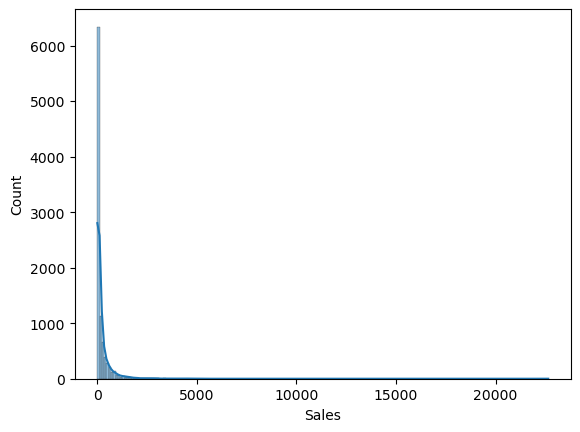

In [52]:
sns.histplot(df['Sales'], kde=True)
plt.show()

BoX PLOT

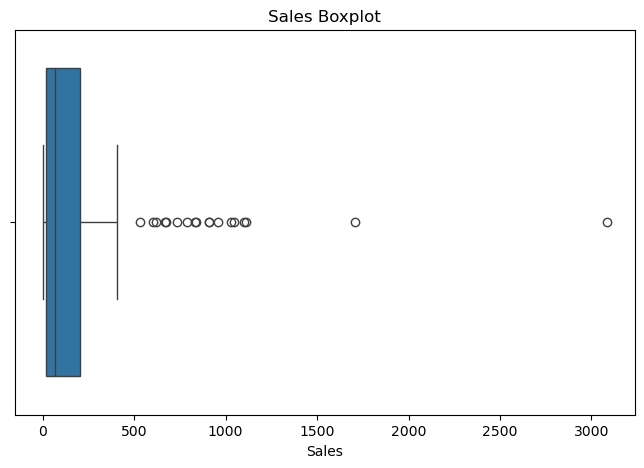

In [65]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Sales'])
plt.title("Sales Boxplot")
plt.show()

BIVARIANT ANAYSIS


CATEGORY WISE SALES

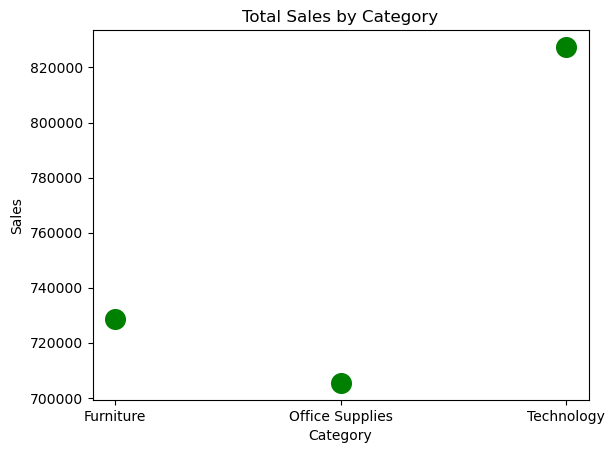

In [54]:
category_sales = df.groupby('Category')['Sales'].sum().reset_index()

plt.scatter(category_sales['Category'],category_sales['Sales'],color = "green",marker = "o",s = 200)

plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.show()

Region-wise Sales

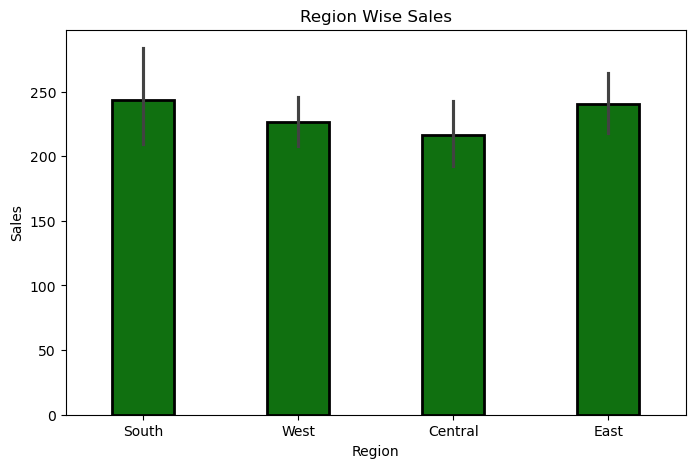

In [55]:
plt.figure(figsize=(8,5))
sns.barplot(x='Region', y='Sales',data = df,color = "green",edgecolor = "black",width=0.4,linewidth = 2)
plt.title("Region Wise Sales")
plt.show()

Top 10 States by Sales

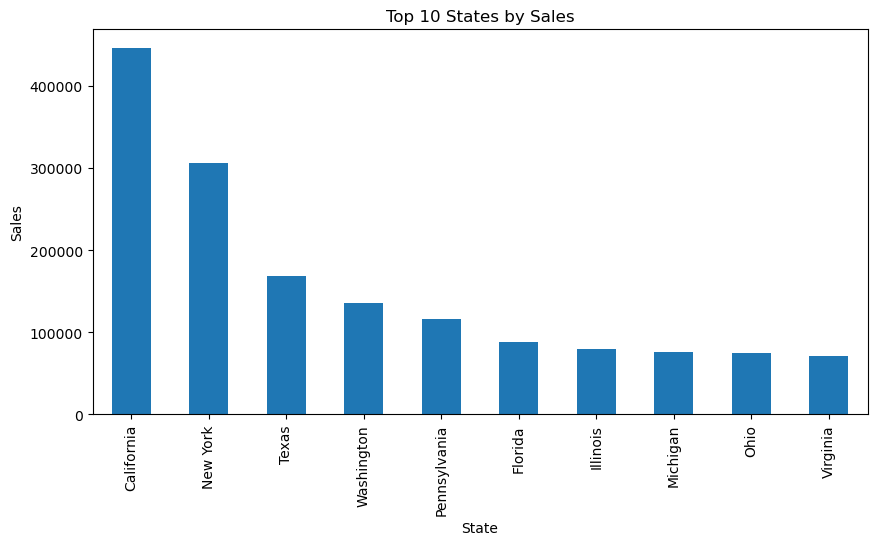

In [56]:
top_states = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_states.plot(kind='bar')
plt.title("Top 10 States by Sales")
plt.ylabel("Sales")
plt.show()

Ship Mode Analysis

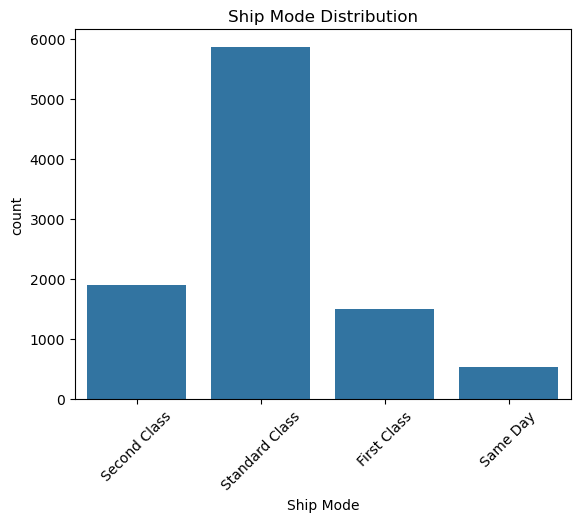

In [57]:
sns.countplot(x='Ship Mode', data=df)
plt.xticks(rotation=45)
plt.title("Ship Mode Distribution")
plt.show()

MULTIVARIANT ANALYSIS

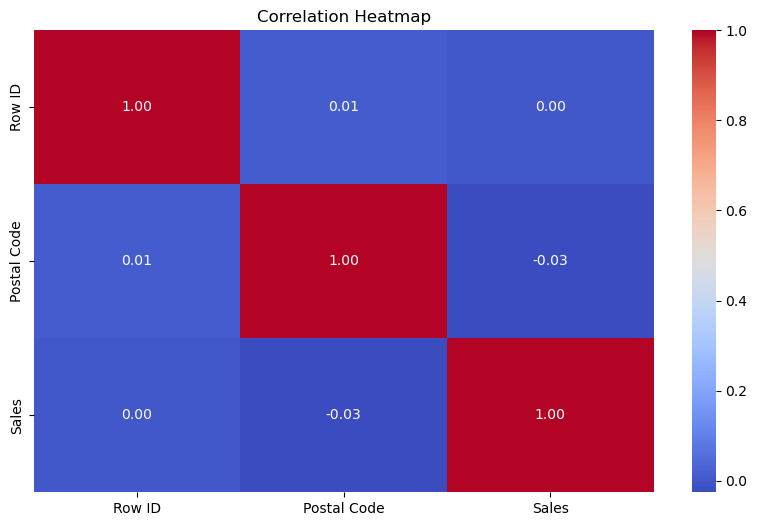

In [58]:
numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title("Correlation Heatmap")
plt.show()

CONNECTING PYTHON TO MYSQL

In [59]:
import sys
!{sys.executable} -m pip install mysql-connector-python

In [60]:
import mysql.connector
conn = mysql.connector.connect(
    host = "localhost",
    user = "root",
    password = "awsm@mysql",
    database = "superstore"
)
cursor = conn.cursor()

SQL QUERIES

In [61]:
query = "select * from sales"
df = pd.read_sql(query,conn)
print(df.head())

   ï»¿Row_ID        Order_ID  Order_Date   Ship_Date       Ship_Mode  \
0          1  CA-2017-152156  08-11-2017  11-11-2017    Second Class   
1          2  CA-2017-152156  08-11-2017  11-11-2017    Second Class   
2          3  CA-2017-138688  12-06-2017  16-06-2017    Second Class   
3          4  US-2016-108966  11-10-2016  18-10-2016  Standard Class   
4          5  US-2016-108966  11-10-2016  18-10-2016  Standard Class   

  Customer_ID    Customer_Name    Segment        Country             City  \
0    CG-12520      Claire Gute   Consumer  United States        Henderson   
1    CG-12520      Claire Gute   Consumer  United States        Henderson   
2    DV-13045  Darrin Van Huff  Corporate  United States      Los Angeles   
3    SO-20335   Sean O'Donnell   Consumer  United States  Fort Lauderdale   
4    SO-20335   Sean O'Donnell   Consumer  United States  Fort Lauderdale   

        State  Postal_Code Region       Product_ID         Category  \
0    Kentucky        42420  South

C:\Users\shaik\AppData\Local\Temp\ipykernel_12388\404935648.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,conn)


In [62]:
query = "select * from sales where Sales>1000"
res = pd.read_sql(query,conn)
print(res)

   ï»¿Row_ID        Order_ID  Order_Date   Ship_Date       Ship_Mode  \
0         11  CA-2015-115812  09-06-2015  14-06-2015  Standard Class   
1         25  CA-2016-106320  25-09-2016  30-09-2016  Standard Class   
2         28  US-2016-150630  17-09-2016  21-09-2016  Standard Class   
3         36  CA-2017-117590  08-12-2017  10-12-2017     First Class   
4         55  CA-2017-105816  11-12-2017  17-12-2017  Standard Class   
5         68  CA-2015-106376  05-12-2015  10-12-2015  Standard Class   

  Customer_ID    Customer_Name    Segment        Country           City  \
0    BH-11710  Brosina Hoffman   Consumer  United States    Los Angeles   
1    EB-13870      Emily Burns   Consumer  United States           Orem   
2    TB-21520  Tracy Blumstein   Consumer  United States   Philadelphia   
3    GH-14485        Gene Hale  Corporate  United States     Richardson   
4    JM-15265   Janet Molinari  Corporate  United States  New York City   
5    BS-11590    Brendan Sweed  Corporate  Un

C:\Users\shaik\AppData\Local\Temp\ipykernel_12388\2568725098.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  res = pd.read_sql(query,conn)


Phone sub-category has highest sales

In [63]:
query = "SELECT Sub_Category,SUM(Sales) AS Total_Sales FROM sales GROUP BY Sub_Category ORDER BY Total_Sales DESC;"
res = pd.read_sql(query,conn)
print(res)

   Sub_Category  Total_Sales
0        Phones    5481.6900
1        Tables    5113.6215
2     Bookcases    3877.7892
3        Chairs    3453.7630
4       Storage    2990.4040
5           Art    1386.6720
6    Appliances    1369.5200
7   Furnishings    1365.8380
8       Binders    1011.7780
9   Accessories     994.4640
10        Paper     743.0880
11    Envelopes     578.6400
12       Labels      95.9600
13    Fasteners      80.8320
14     Supplies      65.8800


C:\Users\shaik\AppData\Local\Temp\ipykernel_12388\826938218.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  res = pd.read_sql(query,conn)


WEST REGION PURCHASES MORE PRODUCTS SO WEST REGION HAS HIGHEST SALES

In [64]:
query = "SELECT Region,SUM(Sales) AS Total_Sales FROM sales GROUP BY Region ORDER BY Total_Sales DESC;"
res = pd.read_sql(query,conn)
print(res)

    Region  Total_Sales
0     West   10189.2780
1  Central    7939.6342
2     East    6327.3280
3    South    4153.6995


C:\Users\shaik\AppData\Local\Temp\ipykernel_12388\2641240527.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  res = pd.read_sql(query,conn)


INSIGHTS FOR ML MODELING

To ensure seamless execution of the machine learning model's .fit() function, missing values were imputed using mode substitution, duplicate records were removed, date columns were converted into numerical features, identifier columns were dropped, outliers in Sales and Profit were treated using clipping/log transformation, and numerical features were standardized. These preprocessing steps eliminated invalid inputs and ensured compatibility with machine learning algorithms.

From the above I Observed the following:
1.Technology category generates the highest sales revenue.
2.Phones are the top-selling sub-category.
3.West region contributes the maximum sales.
4.South region needs improvement and marketing focus.
5.Sales peak during November, indicating strong seasonal demand.
6.Large sales outliers exist and should be handled during analysis.

FUTURE PREDICTION

1.Future monthly sales can be predicted using historical sales trends and time-series analysis.
2.Best-selling products can be identified based on previous sales performance.
3.Seasonal demand patterns can be predicted by analyzing monthly sales variations.
4.Regional growth opportunities can be forecasted by comparing sales across regions.
5.Customer purchasing behavior can be predicted using customer segment and transaction history.
6.These predictions help businesses improve inventory management, marketing strategies, and revenue planning.